# Turtle Trader Strategy — Crypto Replication

Replication of the original Richard Dennis / William Eckhardt Turtle Trading rules
on crypto spot data from DuckDB.

**Original rules (1983):**
- **System 1 (short-term):** Enter long on a 20-day high breakout, exit on a 10-day low breakout
- **System 2 (long-term):** Enter long on a 55-day high breakout, exit on a 20-day low breakout
- **Position sizing:** Risk 1% of equity per unit, where 1 unit = account_risk / (ATR × dollar_per_point)
- **Pyramiding:** Add up to 4 units per market, each 0.5 ATR apart
- **Stops:** 2× ATR from entry price (hard stop)

**Adaptation for crypto:**
- Long-only / cash (no shorting) — consistent with our convexity mandate
- We test both systems plus a combined version
- ATR-based position sizing with configurable risk-per-trade
- We also test a simple binary (equal-weight) variant for comparison
- Applied to top liquid assets individually and as a portfolio

In [5]:
from _setup import *

[setup] Project: trend_crypto  |  DuckDB: /Users/russellfloyd/Dropbox/NRT/nrt_dev/data/market.duckdb
[setup] Ready — np, pd, plt, load_daily_bars, simple_backtest, compute_metrics, ...


## 1. Configuration

In [23]:
# Assets to test
SYMBOLS = ["BTC-USD"]

# Date range
START = "2021-11-01"
END   = "2026-12-31"

# Turtle parameters
SYS1_ENTRY   = 20   # System 1: N-day high breakout for entry
SYS1_EXIT    = 10   # System 1: N-day low breakout for exit
SYS2_ENTRY   = 55   # System 2: N-day high breakout for entry
SYS2_EXIT    = 20   # System 2: N-day low breakout for exit
ATR_PERIOD   = 20   # ATR lookback (Turtles used 20-day "N")
RISK_PER_TRADE = 0.01  # 1% of equity risked per unit
ATR_STOP_MULT  = 2.0   # Hard stop at 2x ATR from entry
MAX_UNITS      = 4     # Maximum pyramid units per position
PYRAMID_ATR    = 0.5   # Add next unit every 0.5 ATR in profit

# Transaction costs
COST_BPS = 20.0

## 2. Load data

In [24]:
panel = load_daily_bars(start=START, end=END)

# Build per-asset OHLCV frames
assets = {}
for sym in SYMBOLS:
    df = panel[panel["symbol"] == sym].copy().sort_values("ts").set_index("ts")
    if len(df) < 100:
        print(f"  {sym}: only {len(df)} bars, skipping")
        continue
    assets[sym] = df
    print(f"  {sym}: {len(df)} bars, {df.index.min().date()} to {df.index.max().date()}")

print(f"\nLoaded {len(assets)} assets")

[data] Loading cached daily bars from /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/_cache/bars_1d_2021-11-01_2026-12-31.parquet
  BTC-USD: 1587 bars, 2021-11-02 to 2026-03-07

Loaded 1 assets


## 3. Core Turtle functions

In [25]:
def compute_atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 20) -> pd.Series:
    """True Range averaged over `period` days (the Turtle 'N')."""
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(period, min_periods=period).mean()


def turtle_signals(
    close: pd.Series, high: pd.Series, low: pd.Series,
    entry_period: int, exit_period: int,
) -> pd.Series:
    """
    Binary Turtle breakout signal.
    Long when close > highest high of prior `entry_period` days.
    Flat when close < lowest low of prior `exit_period` days.
    In between: hold previous state.
    """
    entry_high = high.shift(1).rolling(entry_period, min_periods=entry_period).max()
    exit_low   = low.shift(1).rolling(exit_period, min_periods=exit_period).min()

    signal = pd.Series(np.nan, index=close.index)
    signal[close > entry_high] = 1.0
    signal[close < exit_low]   = 0.0
    signal = signal.ffill().fillna(0.0)
    return signal


def turtle_sized_signal(
    close: pd.Series, high: pd.Series, low: pd.Series,
    atr: pd.Series,
    entry_period: int, exit_period: int,
    risk_per_trade: float = 0.01,
    atr_stop_mult: float = 2.0,
    max_units: int = 4,
    pyramid_atr: float = 0.5,
) -> pd.Series:
    """
    Full Turtle position sizing: ATR-based units with pyramiding and hard stops.
    Returns fractional weight (sum of unit sizes, capped at max_units * unit_size).
    """
    n = len(close)
    pos = np.zeros(n)
    entry_high = high.shift(1).rolling(entry_period, min_periods=entry_period).max().values
    exit_low   = low.shift(1).rolling(exit_period, min_periods=exit_period).min().values
    atr_vals   = atr.values
    close_vals = close.values

    in_trade = False
    units = 0
    entry_price = 0.0
    last_add_price = 0.0
    stop_price = 0.0
    current_atr = 0.0

    for i in range(1, n):
        c = close_vals[i]
        a = atr_vals[i]

        if np.isnan(a) or np.isnan(entry_high[i]) or np.isnan(exit_low[i]):
            pos[i] = 0.0
            continue

        if in_trade:
            # Check hard stop
            if c <= stop_price:
                in_trade = False
                units = 0
                pos[i] = 0.0
                continue

            # Check channel exit
            if c < exit_low[i]:
                in_trade = False
                units = 0
                pos[i] = 0.0
                continue

            # Pyramiding: add unit every pyramid_atr * ATR above last add
            if units < max_units and c >= last_add_price + pyramid_atr * current_atr:
                units += 1
                last_add_price = c
                # Tighten stop: 2*ATR below most recent entry
                stop_price = c - atr_stop_mult * a

            # Unit size: risk_per_trade / (atr_stop_mult * ATR / price)
            unit_weight = risk_per_trade / (atr_stop_mult * a / c) if a > 0 else 0.0
            pos[i] = min(units * unit_weight, 1.0)  # cap total weight at 100%

        else:
            # Check for breakout entry
            if c > entry_high[i]:
                in_trade = True
                units = 1
                entry_price = c
                last_add_price = c
                current_atr = a
                stop_price = c - atr_stop_mult * a

                unit_weight = risk_per_trade / (atr_stop_mult * a / c) if a > 0 else 0.0
                pos[i] = min(unit_weight, 1.0)
            else:
                pos[i] = 0.0

    return pd.Series(pos, index=close.index)

## 4. Generate signals for each asset

In [26]:
all_signals = {}

for sym, df in assets.items():
    close, high, low = df["close"], df["high"], df["low"]
    atr = compute_atr(high, low, close, ATR_PERIOD)

    # Binary signals (simple long/cash)
    s1_bin = turtle_signals(close, high, low, SYS1_ENTRY, SYS1_EXIT)
    s2_bin = turtle_signals(close, high, low, SYS2_ENTRY, SYS2_EXIT)
    combined_bin = ((s1_bin + s2_bin) > 0).astype(float)  # long if either fires

    # ATR-sized signals (full Turtle sizing with pyramiding)
    s1_sized = turtle_sized_signal(
        close, high, low, atr, SYS1_ENTRY, SYS1_EXIT,
        RISK_PER_TRADE, ATR_STOP_MULT, MAX_UNITS, PYRAMID_ATR,
    )
    s2_sized = turtle_sized_signal(
        close, high, low, atr, SYS2_ENTRY, SYS2_EXIT,
        RISK_PER_TRADE, ATR_STOP_MULT, MAX_UNITS, PYRAMID_ATR,
    )
    combined_sized = (s1_sized + s2_sized).clip(upper=1.0)

    all_signals[sym] = {
        "Sys1 Binary": s1_bin,
        "Sys2 Binary": s2_bin,
        "Combined Binary": combined_bin,
        "Sys1 ATR-Sized": s1_sized,
        "Sys2 ATR-Sized": s2_sized,
        "Combined ATR-Sized": combined_sized,
    }

    # Quick diagnostics
    print(f"\n{sym}:")
    for name, sig in all_signals[sym].items():
        tim = sig.mean()
        n_trades = (sig.diff().abs() > 0.01).sum()
        print(f"  {name:22s}  TIM={tim:.1%}  trades={n_trades}  avg_weight={sig[sig>0].mean():.2f}")


BTC-USD:
  Sys1 Binary             TIM=41.3%  trades=45  avg_weight=1.00
  Sys2 Binary             TIM=35.3%  trades=24  avg_weight=1.00
  Combined Binary         TIM=50.2%  trades=45  avg_weight=1.00
  Sys1 ATR-Sized          TIM=16.7%  trades=319  avg_weight=0.44
  Sys2 ATR-Sized          TIM=14.0%  trades=267  avg_weight=0.45
  Combined ATR-Sized      TIM=27.7%  trades=285  avg_weight=0.65


## 5. Per-asset backtest

In [27]:
per_asset_results = {}

for sym, df in assets.items():
    returns = df["close"].pct_change(fill_method=None).dropna()
    ret_df = returns.to_frame(name=sym)

    results = []

    # Buy & Hold benchmark
    bh_w = pd.DataFrame(1.0, index=ret_df.index, columns=[sym])
    results.append(quick_backtest(bh_w, ret_df, COST_BPS, "Buy & Hold"))

    # Each Turtle variant
    for name, sig in all_signals[sym].items():
        w = sig.to_frame(name=sym)
        results.append(quick_backtest(w, ret_df, COST_BPS, name))

    per_asset_results[sym] = results

    print(f"\n{'='*60}")
    print(f"  {sym}")
    print(f"{'='*60}")
    display(metrics_table(results))


  BTC-USD


,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
Buy & Hold,0.067101,1.5%,52.7%,0.29,0.41,0.02,-76.7%,49.1%,0.03,4.029277,1586,0.00,99.9%
Sys1 Binary,0.275492,5.8%,30.6%,0.34,0.32,0.15,-39.6%,19.7%,0.28,10.904375,1586,0.03,41.2%
Sys2 Binary,0.188105,4.0%,27.6%,0.28,0.26,0.14,-29.6%,17.0%,0.69,11.253499,1586,0.02,35.4%
Combined Binary,-0.162654,-4.0%,33.4%,0.04,0.05,-0.09,-44.7%,23.7%,0.23,8.142407,1586,0.03,50.2%
Sys1 ATR-Sized,0.185581,4.0%,14.3%,0.35,0.31,0.20,-19.9%,18.1%,0.93,19.587296,1586,0.02,16.7%
Sys2 ATR-Sized,0.100232,2.2%,12.5%,0.24,0.20,0.15,-15.2%,15.1%,0.95,19.662268,1586,0.01,14.0%
Combined ATR-Sized,0.277259,5.8%,22.2%,0.36,0.35,0.22,-26.5%,20.3%,0.81,14.398187,1586,0.02,27.7%


## 6. Equity curves — per asset

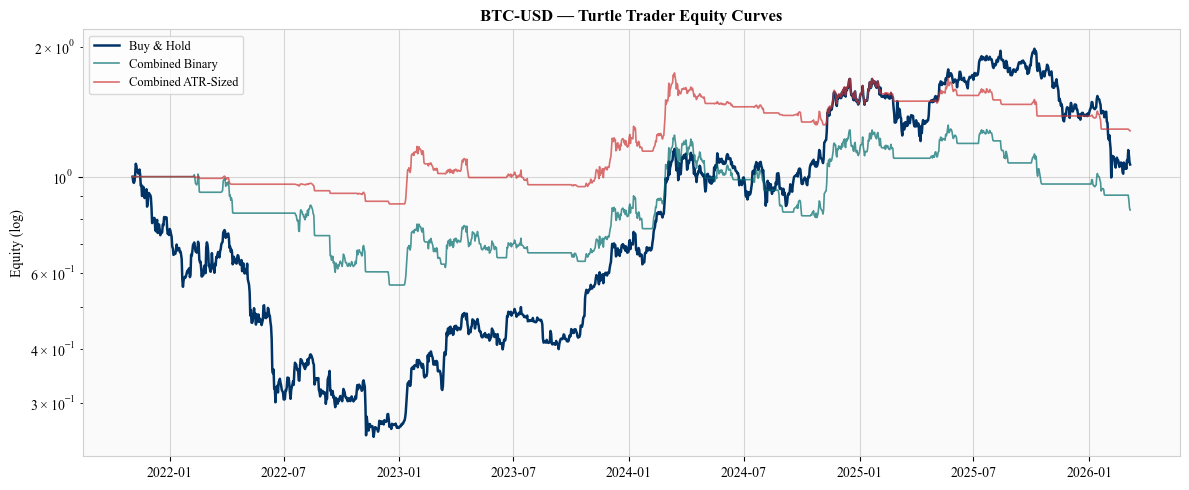

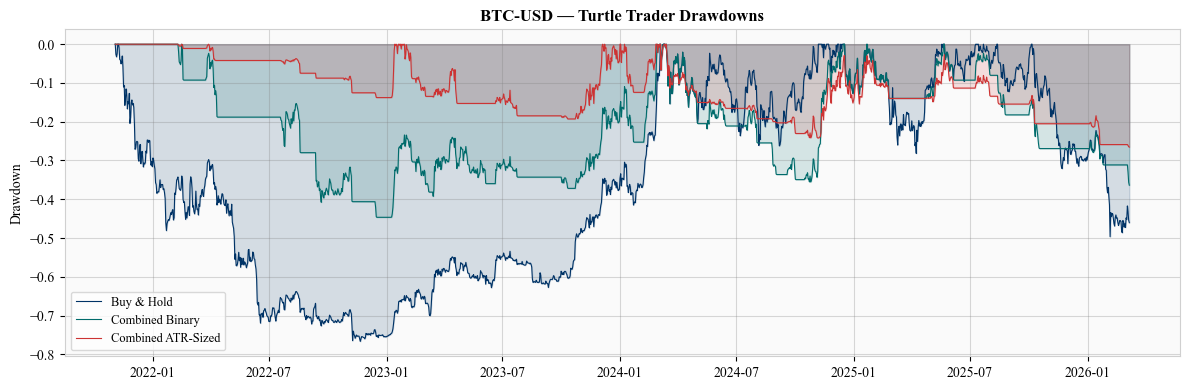

In [28]:
for sym, results in per_asset_results.items():
    # Show the key variants: B&H, Combined Binary, Combined ATR-Sized
    key_results = [r for r in results if r["label"] in ["Buy & Hold", "Combined Binary", "Combined ATR-Sized"]]
    plot_equity(key_results, title=f"{sym} — Turtle Trader Equity Curves")
    plt.show()

    plot_drawdowns(key_results, title=f"{sym} — Turtle Trader Drawdowns")
    plt.show()

## 7. Signal overlay — price + position for each asset

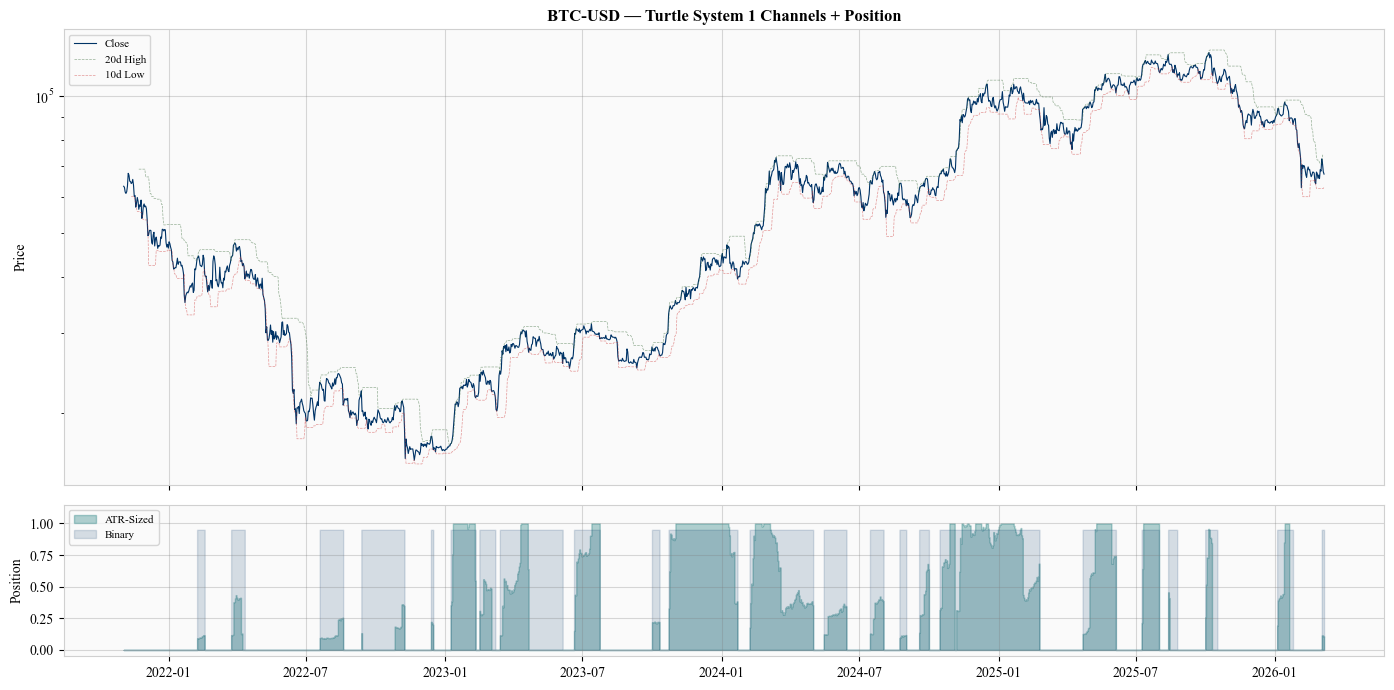

In [29]:
for sym, df in assets.items():
    close = df["close"]
    sig_bin = all_signals[sym]["Combined Binary"]
    sig_sized = all_signals[sym]["Combined ATR-Sized"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(close.index, close.values, color=NAVY, lw=0.8, label="Close")
    atr = compute_atr(df["high"], df["low"], close, ATR_PERIOD)
    entry_hi = df["high"].shift(1).rolling(SYS1_ENTRY).max()
    exit_lo  = df["low"].shift(1).rolling(SYS1_EXIT).min()
    ax1.plot(entry_hi.index, entry_hi.values, color=GREEN, lw=0.5, ls="--", alpha=0.5, label=f"{SYS1_ENTRY}d High")
    ax1.plot(exit_lo.index, exit_lo.values, color=RED, lw=0.5, ls="--", alpha=0.5, label=f"{SYS1_EXIT}d Low")
    ax1.set_ylabel("Price")
    ax1.set_title(f"{sym} — Turtle System 1 Channels + Position", fontweight="bold")
    ax1.legend(fontsize=8, loc="upper left")
    ax1.set_yscale("log")

    ax2.fill_between(sig_sized.index, sig_sized.values, alpha=0.3, color=TEAL, step="post", label="ATR-Sized")
    ax2.fill_between(sig_bin.index, sig_bin.values * 0.95, alpha=0.15, color=NAVY, step="post", label="Binary")
    ax2.set_ylabel("Position")
    ax2.set_ylim(-0.05, 1.15)
    ax2.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

## 8. Multi-asset portfolio

Equal-risk allocation across assets using inverse-vol weighting, then overlay the Turtle signals.

In [15]:
# Build wide returns and weights
close_wide = pd.DataFrame({sym: df["close"] for sym, df in assets.items()})
returns_wide = close_wide.pct_change(fill_method=None)

# Combined ATR-Sized across assets
weights_sized = pd.DataFrame({
    sym: all_signals[sym]["Combined ATR-Sized"]
    for sym in assets
}).reindex(returns_wide.index).fillna(0.0)

# Normalize so total weight <= 1.0 (equal allocation budget per asset)
n_assets = len(assets)
weights_sized_normed = weights_sized / n_assets

# Combined Binary across assets (equal weight when in)
weights_binary = pd.DataFrame({
    sym: all_signals[sym]["Combined Binary"]
    for sym in assets
}).reindex(returns_wide.index).fillna(0.0)
weights_binary_normed = weights_binary / n_assets

# Equal-weight buy & hold
bh_wide = pd.DataFrame(1.0 / n_assets, index=returns_wide.index, columns=returns_wide.columns)

# Run portfolio backtests
port_results = [
    quick_backtest(weights_sized_normed, returns_wide, COST_BPS, "Turtle ATR-Sized Portfolio"),
    quick_backtest(weights_binary_normed, returns_wide, COST_BPS, "Turtle Binary Portfolio"),
    quick_backtest(bh_wide, returns_wide, COST_BPS, "EW Buy & Hold"),
]

print("Portfolio-level results:")
display(metrics_table(port_results))

Portfolio-level results:


,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
Turtle ATR-Sized Portfolio,0.412934,8.3%,14.0%,0.64,0.63,0.65,-12.7%,25.4%,0.39,13.597551,1587,0.01,14.1%
Turtle Binary Portfolio,1.032573,17.7%,34.7%,0.64,0.78,0.53,-33.3%,30.3%,0.64,7.091179,1587,0.02,37.9%
EW Buy & Hold,-0.277326,-7.2%,65.4%,0.21,0.32,-0.10,-73.0%,49.3%,0.08,2.935274,1587,0.00,99.9%


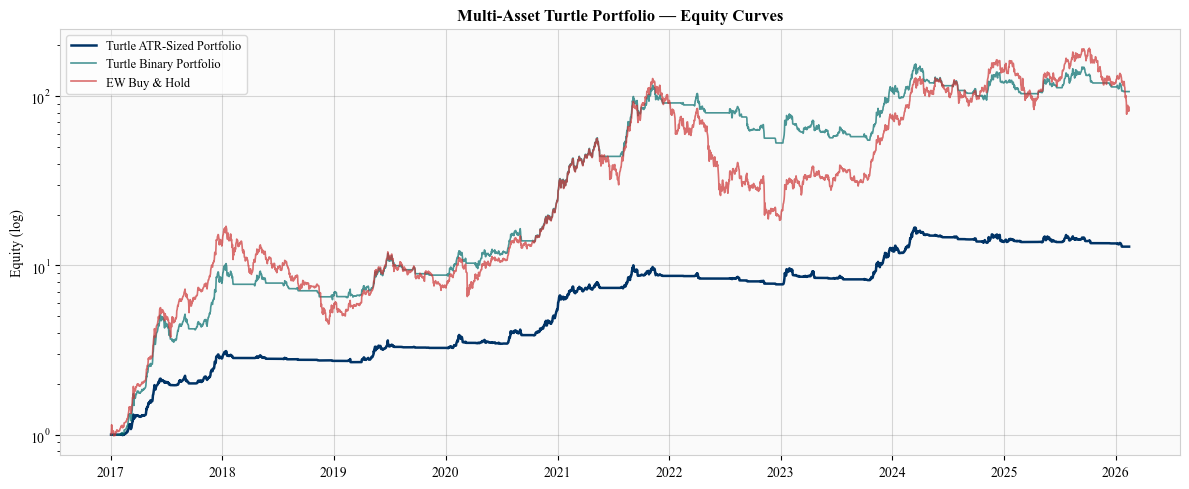

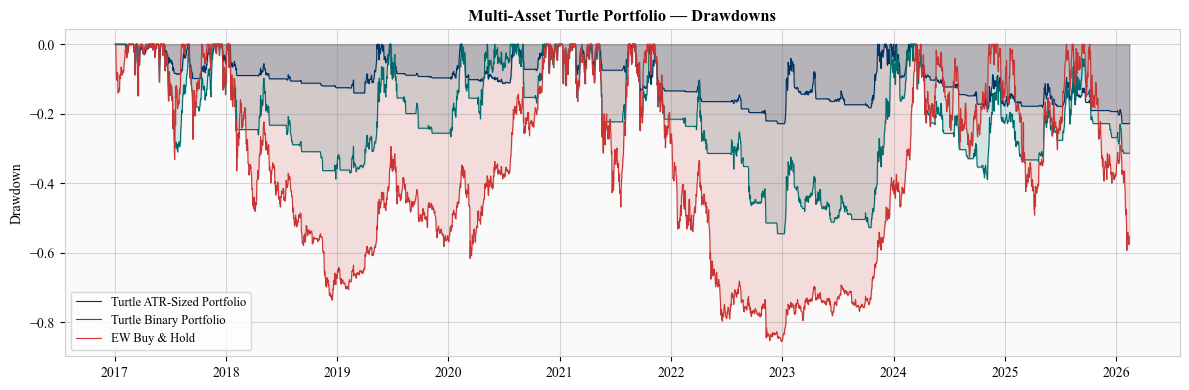

In [12]:
plot_equity(port_results, title="Multi-Asset Turtle Portfolio — Equity Curves")
plt.show()

plot_drawdowns(port_results, title="Multi-Asset Turtle Portfolio — Drawdowns")
plt.show()

## 9. Parameter sensitivity

Sweep key Turtle parameters on a single asset to understand sensitivity.

In [16]:
SWEEP_SYMBOL = "ETH-USD"
sweep_df = assets[SWEEP_SYMBOL]
sweep_close = sweep_df["close"]
sweep_high  = sweep_df["high"]
sweep_low   = sweep_df["low"]
sweep_ret   = sweep_close.pct_change(fill_method=None).dropna().to_frame(name=SWEEP_SYMBOL)

# Sweep entry/exit period combinations
entry_periods = [10, 20, 30, 40, 55, 80]
exit_periods  = [5, 10, 15, 20, 30]

sweep_rows = []
for ep in entry_periods:
    for xp in exit_periods:
        if xp >= ep:
            continue
        sig = turtle_signals(sweep_close, sweep_high, sweep_low, ep, xp)
        w = sig.to_frame(name=SWEEP_SYMBOL)
        r = quick_backtest(w, sweep_ret, COST_BPS, f"E{ep}/X{xp}")
        if r["metrics"]:
            sweep_rows.append({
                "entry": ep, "exit": xp,
                "sharpe": r["metrics"]["sharpe"],
                "cagr": r["metrics"]["cagr"],
                "max_dd": r["metrics"]["max_dd"],
                "tim": float(sig.mean()),
                "calmar": r["metrics"]["calmar"],
            })

sweep_df_result = pd.DataFrame(sweep_rows)
print(f"Tested {len(sweep_rows)} entry/exit combinations on {SWEEP_SYMBOL}")
display(sweep_df_result.sort_values("sharpe", ascending=False).round(3).head(15))

Tested 23 entry/exit combinations on ETH-USD


,entry,exit,sharpe,cagr,max_dd,tim,calmar
21,80,20,0.777,0.197,-0.312,0.219,0.632
20,80,15,0.643,0.151,-0.312,0.215,0.483
13,55,5,0.621,0.142,-0.238,0.228,0.596
19,80,10,0.612,0.135,-0.279,0.168,0.483
18,80,5,0.595,0.119,-0.235,0.157,0.505
22,80,30,0.519,0.122,-0.422,0.265,0.290
16,55,20,0.513,0.124,-0.449,0.333,0.276
8,40,5,0.481,0.104,-0.238,0.247,0.436
7,30,20,0.474,0.116,-0.534,0.402,0.218
14,55,10,0.465,0.101,-0.271,0.245,0.372


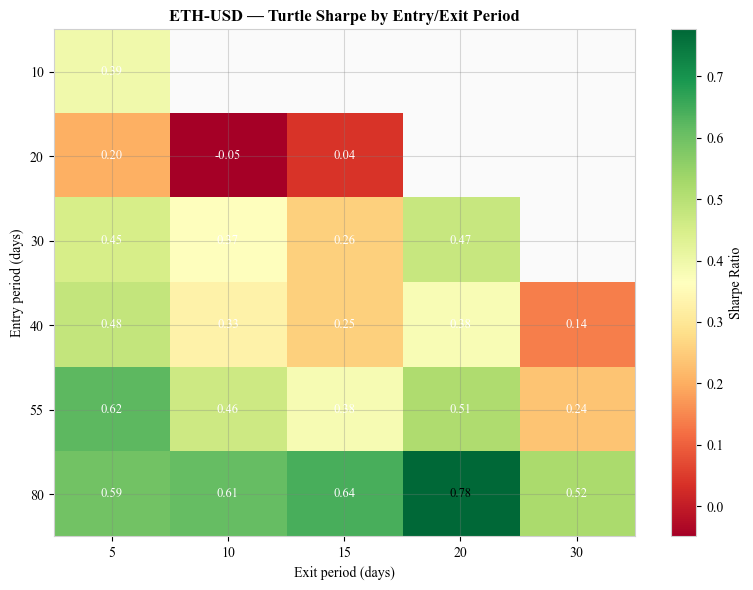

In [17]:
# Heatmap: Sharpe by entry/exit period
pivot = sweep_df_result.pivot(index="entry", columns="exit", values="sharpe")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
               vmin=pivot.values[~np.isnan(pivot.values)].min(),
               vmax=pivot.values[~np.isnan(pivot.values)].max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Exit period (days)")
ax.set_ylabel("Entry period (days)")
ax.set_title(f"{SWEEP_SYMBOL} — Turtle Sharpe by Entry/Exit Period", fontweight="bold")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if val < 0.7 else "black")

fig.colorbar(im, ax=ax, label="Sharpe Ratio")
fig.tight_layout()
plt.show()

## 10. Year-by-year performance

In [18]:
# Year-by-year breakdown for the Combined ATR-Sized on each asset
for sym in assets:
    results_key = [r for r in per_asset_results[sym] if r["label"] in ["Buy & Hold", "Combined ATR-Sized"]]

    print(f"\n{'='*50}")
    print(f"  {sym} — Year-by-Year")
    print(f"{'='*50}")

    for r in results_key:
        eq = r["equity"]
        if eq.empty:
            continue
        eq.index = pd.to_datetime(eq.index)
        annual_ret = eq.resample("YE").last().pct_change().dropna()
        annual_ret.index = annual_ret.index.year
        print(f"\n  {r['label']}:")
        for yr, ret in annual_ret.items():
            print(f"    {yr}: {ret:+.1%}")


  BTC-USD — Year-by-Year

  Buy & Hold:
    2022: -64.2%
    2023: +155.8%
    2024: +120.8%
    2025: -6.3%
    2026: -23.1%

  Combined ATR-Sized:
    2022: -13.5%
    2023: +36.1%
    2024: +26.2%
    2025: -7.0%
    2026: -7.6%

  ETH-USD — Year-by-Year

  Buy & Hold:
    2022: -67.5%
    2023: +90.8%
    2024: +46.0%
    2025: -10.9%
    2026: -33.9%

  Combined ATR-Sized:
    2022: -14.3%
    2023: +31.5%
    2024: +18.8%
    2025: +9.4%
    2026: -3.8%

  SOL-USD — Year-by-Year

  Buy & Hold:
    2022: -94.1%
    2023: +920.0%
    2024: +85.7%
    2025: -34.1%
    2026: -33.7%

  Combined ATR-Sized:
    2022: -4.9%
    2023: +112.4%
    2024: -7.7%
    2025: -10.0%
    2026: -2.3%

  ETC-USD — Year-by-Year

  Buy & Hold:
    2022: -53.9%
    2023: +39.6%
    2024: +13.9%
    2025: -54.1%
    2026: -28.9%

  Combined ATR-Sized:
    2022: +8.2%
    2023: -8.8%
    2024: -12.2%
    2025: +0.9%
    2026: -1.1%

  SUI-USD — Year-by-Year

  Buy & Hold:
    2024: +430.9%
    2025: -65

## 11. Summary & observations

Key questions to evaluate:

1. **Does the Turtle system work on crypto?** Compare Sharpe to B&H across assets.
2. **Binary vs ATR-sized:** Does full Turtle sizing (with pyramiding) add value vs. simple binary?
3. **System 1 vs System 2:** Does the shorter-term breakout add enough vs. the longer-term?
4. **Drawdown compression:** How much does the channel exit reduce max DD vs. B&H?
5. **Parameter sensitivity:** Is the optimal entry/exit period stable or fragile?
6. **Year-by-year:** Does it protect in bear years (2018, 2022) while participating in bulls?

In [19]:
# Final summary table: best variant per asset
summary_rows = []
for sym, results in per_asset_results.items():
    for r in results:
        m = r.get("metrics", {})
        if not m:
            continue
        summary_rows.append({
            "asset": sym,
            "strategy": r["label"],
            "sharpe": m.get("sharpe"),
            "cagr": m.get("cagr"),
            "max_dd": m.get("max_dd"),
            "calmar": m.get("calmar"),
            "skewness": m.get("skewness"),
        })

summary = pd.DataFrame(summary_rows)
summary["cagr"] = summary["cagr"].map("{:.1%}".format)
summary["max_dd"] = summary["max_dd"].map("{:.1%}".format)
summary[["sharpe", "calmar", "skewness"]] = summary[["sharpe", "calmar", "skewness"]].round(2)

display(summary.set_index(["asset", "strategy"]))

sharpe    cagr  max_dd  calmar  skewness
asset   strategy                                                    
BTC-USD Buy & Hold            0.29    1.5%  -76.7%    0.02      0.03
        Sys1 Binary           0.34    5.8%  -39.6%    0.15      0.28
        Sys2 Binary           0.28    4.0%  -29.6%    0.14      0.69
        Combined Binary       0.04   -4.0%  -44.7%   -0.09      0.23
        Sys1 ATR-Sized        0.35    4.0%  -19.9%    0.20      0.93
        Sys2 ATR-Sized        0.24    2.2%  -15.2%    0.15      0.95
        Combined ATR-Sized    0.36    5.8%  -26.5%    0.22      0.81
ETH-USD Buy & Hold            0.08  -17.9%  -79.4%   -0.23      0.23
        Sys1 Binary          -0.05   -9.1%  -53.6%   -0.17      0.54
        Sys2 Binary           0.51   12.4%  -44.9%    0.28      0.55
        Combined Binary       0.05   -6.1%  -54.5%   -0.11      0.40
        Sys1 ATR-Sized        0.22    2.0%  -19.2%    0.10      0.99
        Sys2 ATR-Sized        0.71    8.4%  -14.1%    0.60      1.56
        Combined ATR-Sized    0.46    8.2%  -29.6%    0.28      1.00
SOL-USD Buy & Hold            0.23  -22.1%  -96.3%   -0.23      0.08
        Sys1 Binary           0.62   21.4%  -66.8%    0.32      1.98
        Sys2 Binary           0.48   12.4%  -68.0%    0.18      2.38
        Combined Binary       0.43    9.1%  -68.7%    0.13      1.77
        Sys1 ATR-Sized        0.56    6.5%  -16.0%    0.41      1.94
        Sys2 ATR-Sized        0.64    6.3%  -17.1%    0.37      2.30
        Combined ATR-Sized    0.62   12.1%  -31.3%    0.38      2.26
ETC-USD Buy & Hold           -0.08  -35.7%  -86.8%   -0.41      1.08
        Sys1 Binary           0.18   -3.9%  -64.9%   -0.06      3.76
        Sys2 Binary           0.15   -4.4%  -55.2%   -0.08      2.61
        Combined Binary       0.30    1.4%  -58.8%    0.02      3.12
        Sys1 ATR-Sized        0.10    0.6%  -16.1%    0.03      4.03
        Sys2 ATR-Sized       -0.60   -3.4%  -16.4%   -0.21      0.48
        Combined ATR-Sized   -0.15   -3.3%  -29.7%   -0.11      2.21
SUI-USD Buy & Hold            0.44   -8.2%  -83.7%   -0.10      0.93
        Sys1 Binary           1.23   83.2%  -35.2%    2.36      2.46
        Sys2 Binary           1.37  101.6%  -45.4%    2.24      2.30
        Combined Binary       1.41  115.1%  -41.9%    2.75      2.03
        Sys1 ATR-Sized        0.91   10.1%   -7.6%    1.33      1.89
        Sys2 ATR-Sized        1.05   12.3%   -7.4%    1.66      2.14
        Combined ATR-Sized    1.03   22.4%  -14.1%    1.60      1.96